Caderno Jupyter para testes de treinamento em ML

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import sklearn 

In [4]:
df = pd.read_csv('Sleep_health_and_lifestyle_dataset.csv')
df["Sleep Disorder"] = df["Sleep Disorder"].fillna("None")
# print(df["Sleep Disorder"].value_counts())

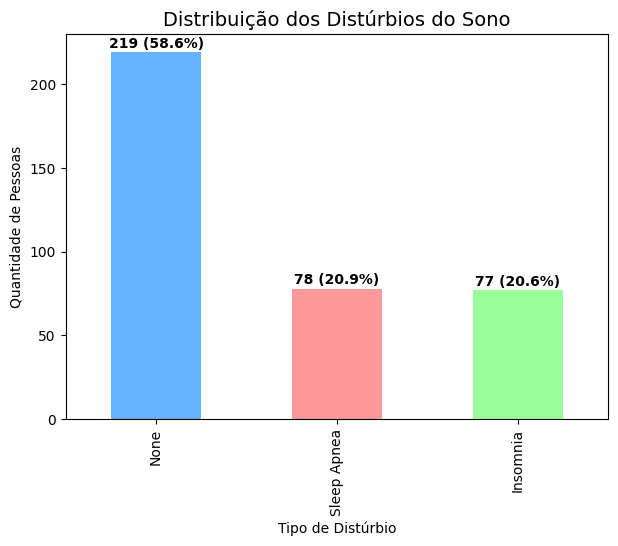

In [5]:
contagem = df["Sleep Disorder"].value_counts()
total = contagem.sum()

plt.figure(figsize=(7,5))
ax = contagem.plot(kind="bar", color=["#66b3ff", "#ff9999", "#99ff99"])

plt.title("Distribuição dos Distúrbios do Sono", fontsize=14)
plt.xlabel("Tipo de Distúrbio")
plt.ylabel("Quantidade de Pessoas")

for i, v in enumerate(contagem):
    percentual = (v / total) * 100
    ax.text(i, v + 1, f"{v} ({percentual:.1f}%)", 
            ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.show()

In [6]:
# Mantém apenas as linhas com algum distúrbio (descarta 'None')
df = df[df["Sleep Disorder"].notna()]

# Mantém apenas Insomnia e Sleep Apnea
df = df[df["Sleep Disorder"].isin(["Insomnia", "Sleep Apnea"])]

# Coluna alvo (o que queremos prever)
y = df["Sleep Disorder"]

# Colunas que vamos usar para prever
X = df[["Age", "Sleep Duration", "Quality of Sleep",
        "Physical Activity Level", "Stress Level",
        "Heart Rate", "Daily Steps"]]

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Ver quais números correspondem a quais distúrbios
print(dict(zip(le.classes_, le.transform(le.classes_))))


{'Insomnia': np.int64(0), 'Sleep Apnea': np.int64(1)}


In [37]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)
from sklearn.ensemble import RandomForestClassifier

modelo = RandomForestClassifier(random_state=42)
modelo.fit(X_train, y_train)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [40]:
from sklearn.metrics import classification_report

y_pred = modelo.predict(X_test)

print("Relatório de Classificação:\n")
print(classification_report(y_test, y_pred, target_names=le.classes_))



Relatório de Classificação:

              precision    recall  f1-score   support

    Insomnia       0.81      0.87      0.84        15
 Sleep Apnea       0.87      0.81      0.84        16

    accuracy                           0.84        31
   macro avg       0.84      0.84      0.84        31
weighted avg       0.84      0.84      0.84        31

